# Libraries

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from src.dataset import ARCADEDataset

#  Dataset Sample Visualization

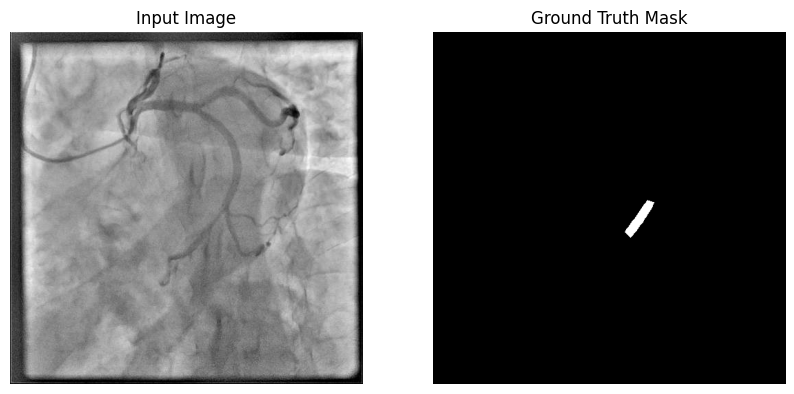

In [10]:
train_dataset = ARCADEDataset(root_dir="arcade/stenosis", split="train", image_size=(512, 512), augment=True)
image, mask = train_dataset[0]
# Convert image from [-1, 1] to [0, 1]
image = (image + 1.0) / 2.0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

#  Train

In [3]:
!python -m src.train

Device: cuda
Mixed Precision FP16: Enabled
Batch size: 8
Epochs: 50
Training samples: 1000
Validation samples: 200

--------------------------------------------------
Epoch [1/50]
--------------------------------------------------
Validation: 100%|████| 25/25 [-01:47<00:00, -0.23it/s, dice=0.0000, loss=1.3250]

Train Loss: 1.4045
Train Dice: 0.0072
Val Loss:   1.3276
Val Dice:   0.0004

Best model saved
Best Val Dice: 0.0004

--------------------------------------------------
Epoch [2/50]
--------------------------------------------------
Validation: 100%|█████| 25/25 [00:06<00:00,  3.91it/s, dice=0.0148, loss=1.2685]

Train Loss: 1.2838
Train Dice: 0.0062
Val Loss:   1.2709
Val Dice:   0.0191

Best model saved
Best Val Dice: 0.0191

--------------------------------------------------
Epoch [3/50]
--------------------------------------------------
Validation: 100%|█████| 25/25 [00:06<00:00,  4.12it/s, dice=0.1490, loss=1.1957]

Train Loss: 1.2214
Train Dice: 0.0616
Val Loss:   1.2017
Va

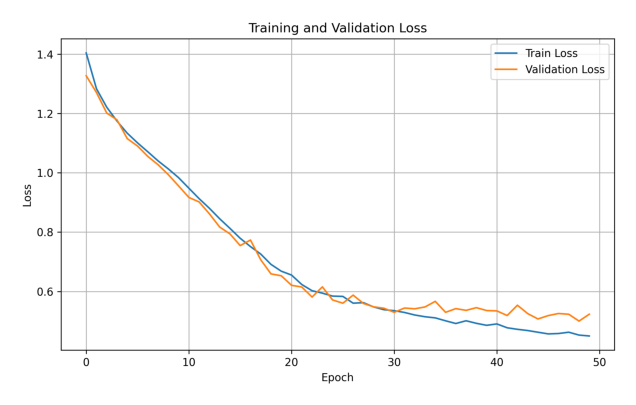

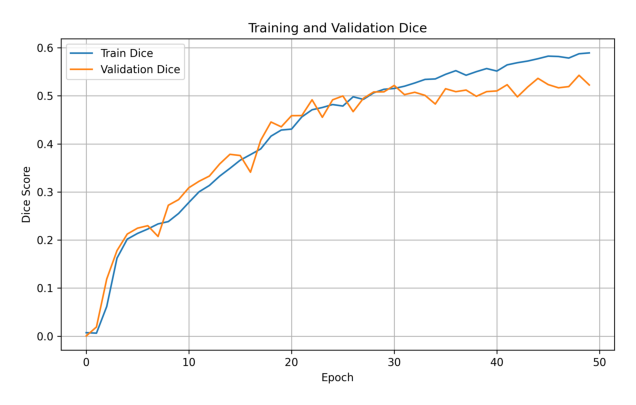

In [4]:
loss_curve = Image.open("results/loss_curve.png")
dice_curve = Image.open("results/dice_curve.png")

plt.figure(figsize=(8, 5))
plt.imshow(loss_curve)
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(dice_curve)
plt.axis("off")
plt.show()

# Evaluation

In [7]:
!python -m src.evaluate

Device: cuda
Model: results/best_model.pth
Test samples: 300
Evaluation: 100%|██████████████████| 38/38 [00:15<00:00,  2.39it/s, dice=0.5104]

--------------------------------------------------
Evaluation completed.
--------------------------------------------------
Test Dice: 0.4959
Saved predictions: 10
Output directory: results/predictions


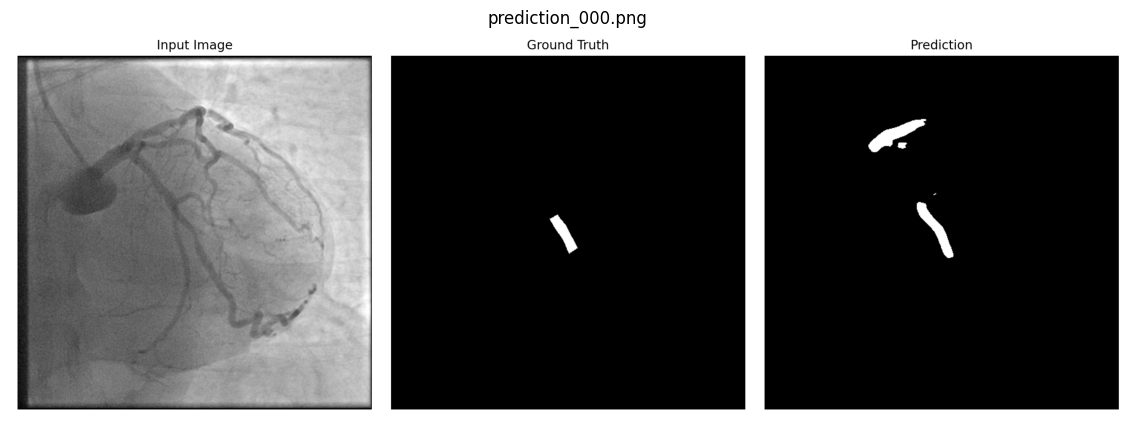

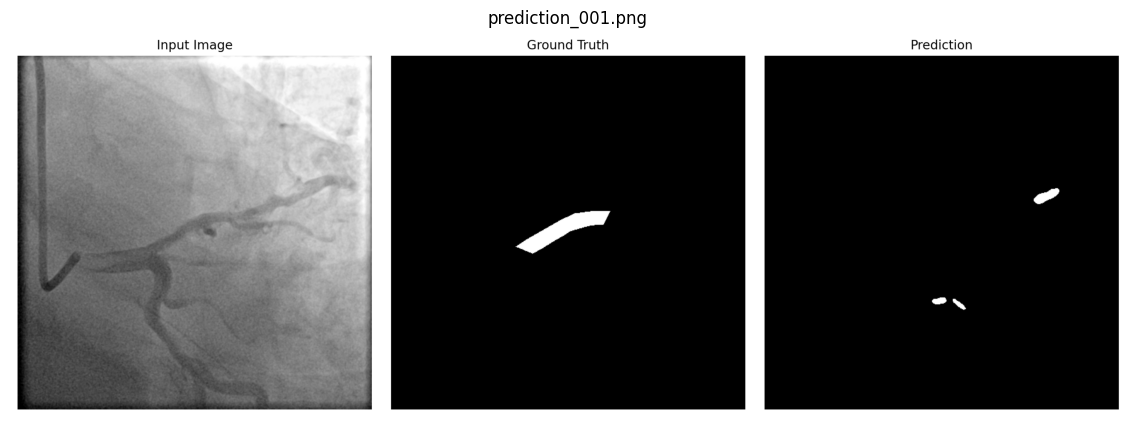

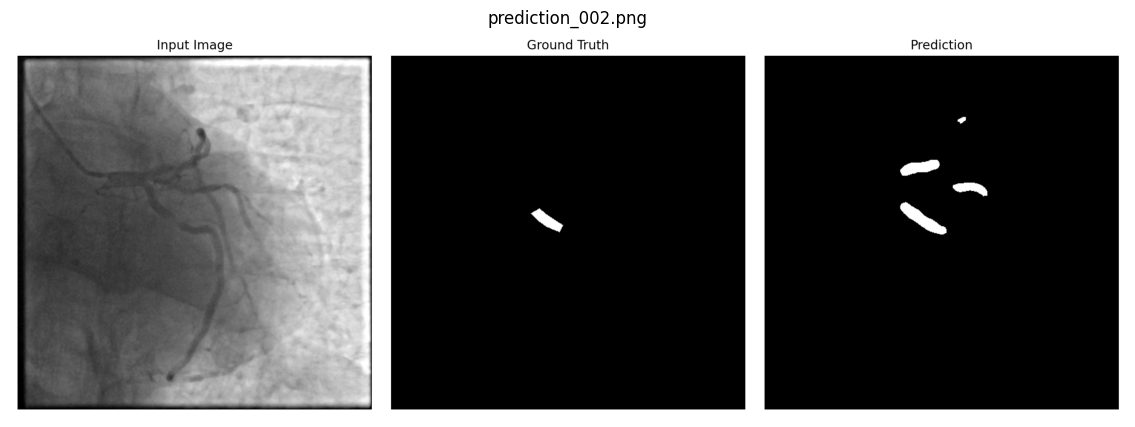

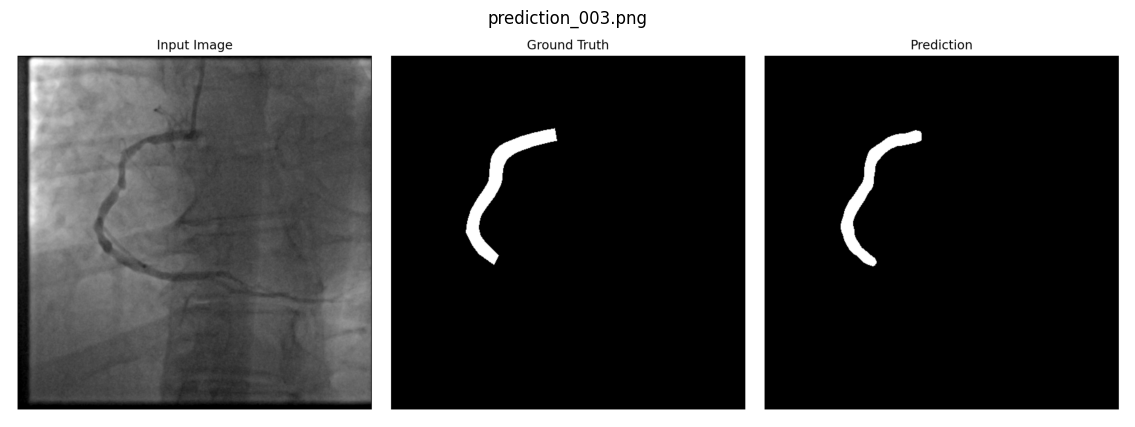

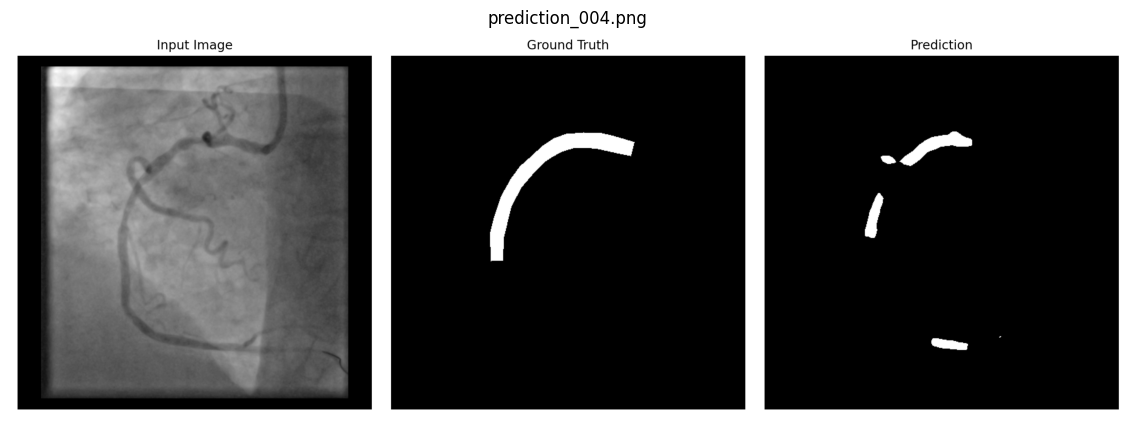

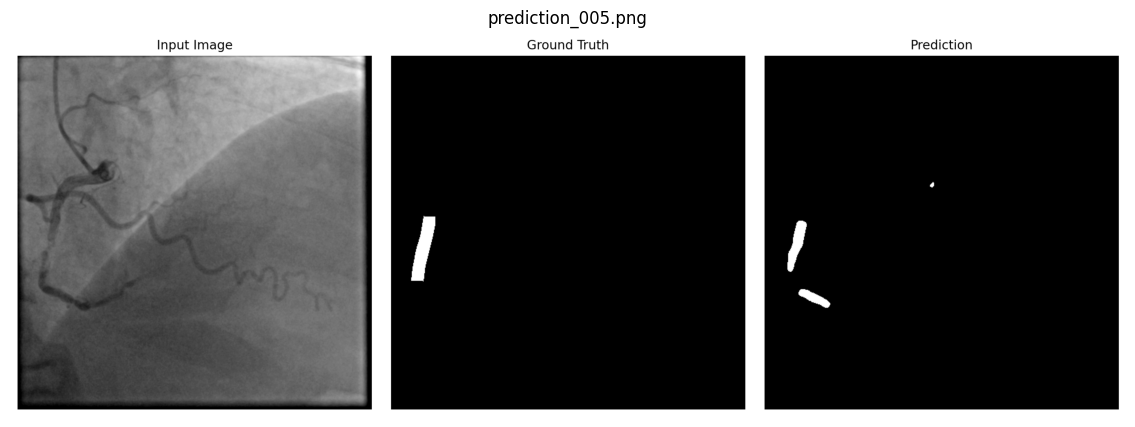

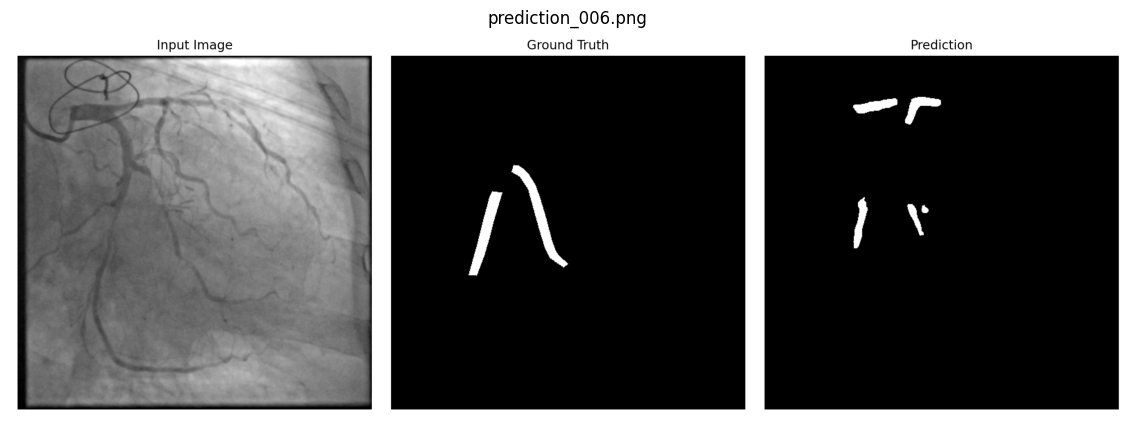

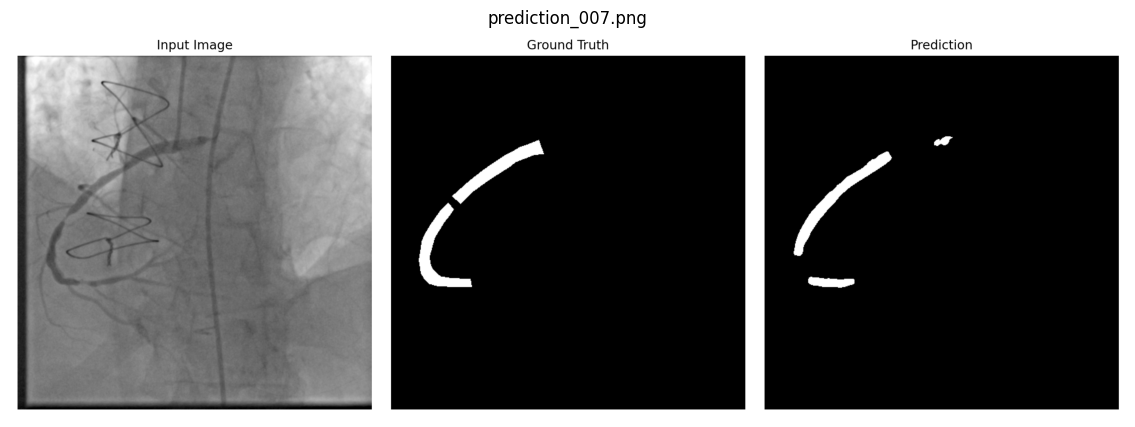

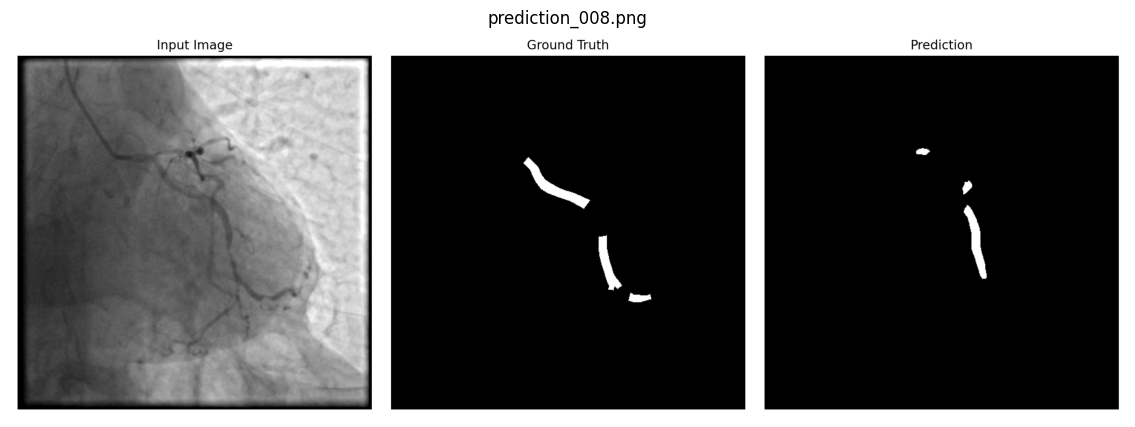

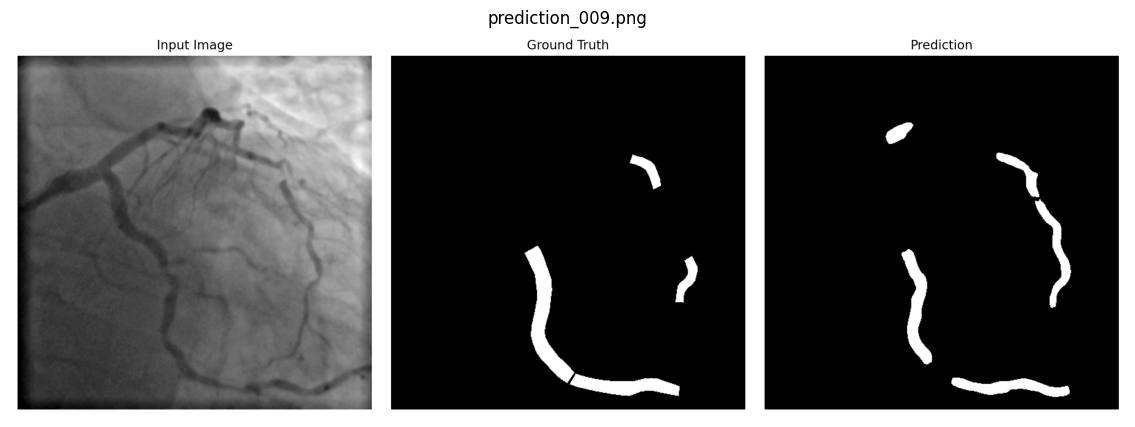

In [8]:
prediction_dir = "results/predictions"

files = sorted([
    f for f in os.listdir(prediction_dir)
    if f.endswith(".png")
])

for file in files:
    
    image = Image.open(os.path.join(prediction_dir, file))
    
    plt.figure(figsize=(15, 5))
    plt.imshow(image)
    plt.title(file)
    plt.axis("off")
    plt.show()